## Import

In [1]:
from hyperopt import hp, tpe, Trials
from hyperopt.fmin import fmin
from hyperopt.pyll import scope

from xgboost import XGBRegressor

from lightgbm import LGBMRegressor, LGBMClassifier

from catboost import CatBoostRegressor

from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

c:\Users\jingni\AppData\Local\Programs\Python\Python313\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import os

import gdown

import scipy

import numpy as np

import matplotlib.pyplot as plt

import tqdm.auto as tqdm

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from ipywidgets import interactive, fixed, interact_manual, IntSlider, FloatLogSlider, FloatSlider

import torch
from torchvision.datasets import CIFAR10

from keras.applications.inception_v3 import InceptionV3, preprocess_input

import sklearn

from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

from sklearn.manifold import TSNE, Isomap

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.preprocessing import StandardScaler, MinMaxScaler
%matplotlib inline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, make_scorer



import matplotlib.pyplot as plt

import pandas as pd

import time
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter("ignore", category=ConvergenceWarning)
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool, cv
import pandas as pd

Импорт библиотек(далеко не всё я использовала, некоторые просто на всякий случай)

## Data

Импортирование данных

In [23]:
y_sub = pd.DataFrame(pd.read_csv("sample_submission.csv"))
X_test = pd.DataFrame(pd.read_csv("test.csv"))
df_web = pd.DataFrame(pd.read_csv("t1_webstat.csv"))
train = pd.DataFrame(pd.read_csv("train.csv"))
X_train = train.loc[:, train.columns != 'is_callcenter']
y_train = train[['order_id', 'is_callcenter']].copy()

In [24]:
# df_web['pageview_duration_sec'] = df_web['pageview_duration_sec'].abs() # почему-то это ухудшает результат, хотя есть отрицательное значение времени просмотра старницы

In [25]:
web_train = df_web[df_web['sessionkey_id'].isin(X_train['sessionkey_id'])]
web_test = df_web[df_web['sessionkey_id'].isin(X_test['sessionkey_id'])]

In [26]:
web_train.isnull().sum()

sessionkey_id                 0
date_time                     0
page_type                     0
pageview_number               0
pageview_duration_sec     59119
category_id              299168
model_id                 580749
good_id                  589666
price                    589666
product_in_sale          589666
dtype: int64

In [27]:
web_train = web_train.drop([ # слишком много пропусков
            'price',
            'product_in_sale'
            ], axis=1)

In [28]:
web_test = web_test.drop([
            'price',
            'product_in_sale'
            ], axis=1)

In [29]:
web_train.columns

Index(['sessionkey_id', 'date_time', 'page_type', 'pageview_number',
       'pageview_duration_sec', 'category_id', 'model_id', 'good_id'],
      dtype='object')

In [30]:
def data_conv(df):
    df["create_time"] = pd.to_datetime(df["create_time"])
    df["weekday"] = df["create_time"].dt.weekday
    df["hour"] = df["create_time"].dt.hour
    df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)
    return df

In [31]:
X_train = data_conv(X_train)
X_test = data_conv(X_test)

C:\Users\jingni\AppData\Local\Temp\ipykernel_15896\3875712237.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["create_time"] = pd.to_datetime(df["create_time"])


In [32]:
X_train.columns

Index(['Unnamed: 0', 'order_id', 'create_time', 'good_id', 'price',
       'utm_medium', 'utm_source', 'sessionkey_id', 'category_id', 'parent_id',
       'root_id', 'model_id', 'is_moderated', 'rating_value', 'rating_count',
       'description_length', 'goods_qty', 'pics_qty', 'model_create_time',
       'weekday', 'hour', 'is_weekend'],
      dtype='object')

In [33]:
X_train= X_train.drop([
            'order_id',
            'model_create_time',
            'goods_qty',
            'create_time',
            'model_id'
            # 'parent_id',
            # 'category_id'
            ], axis=1)

In [34]:
X_test= X_test.drop([
            'order_id',
            'model_create_time',
            'goods_qty',
            'create_time',
            'model_id'
            # 'parent_id',
            # 'category_id'
            ], axis=1)

In [35]:
# НЕ УДАЛЯЙ ЗАПАСНОЙ ТРЕЙН С ОТВЕТАМИ
X_train["is_callcenter"] = y_train["is_callcenter"].values
X_trainc = X_train.copy()
X_train = X_train.drop(['is_callcenter'] ,axis = 1)

## Data 2

Здесь немного больше работы с колонками и объединение вебстатов с трейном через sessionkey_id

In [36]:
X_trainc.columns

Index(['Unnamed: 0', 'good_id', 'price', 'utm_medium', 'utm_source',
       'sessionkey_id', 'category_id', 'parent_id', 'root_id', 'is_moderated',
       'rating_value', 'rating_count', 'description_length', 'pics_qty',
       'weekday', 'hour', 'is_weekend', 'is_callcenter'],
      dtype='object')

In [37]:
X_test.columns

Index(['Unnamed: 0', 'good_id', 'price', 'utm_medium', 'utm_source',
       'sessionkey_id', 'category_id', 'parent_id', 'root_id', 'is_moderated',
       'rating_value', 'rating_count', 'description_length', 'pics_qty',
       'weekday', 'hour', 'is_weekend'],
      dtype='object')

In [38]:
web_train.columns

Index(['sessionkey_id', 'date_time', 'page_type', 'pageview_number',
       'pageview_duration_sec', 'category_id', 'model_id', 'good_id'],
      dtype='object')

In [39]:
def ff(web_train, X_trainc, top_bi=None):
    web = web_train.copy()
    X = X_trainc.copy()

    X['root_freq'] = X['root_id'].map(X['root_id'].value_counts(normalize=True))
    #X['cat_freq'] = X['category_id'].map(X['category_id'].value_counts(normalize=True))
    #X['parent_freq'] = X['parent_id'].map(X['parent_id'].value_counts(normalize=True))
    X['utm_freq'] = X['utm_medium'].map(X['utm_medium'].value_counts(normalize=True))

    web['date_time'] = pd.to_datetime(web['date_time'])
    web = web.sort_values(['sessionkey_id', 'date_time'])
    web['time_diff'] = web.groupby('sessionkey_id')['date_time'].diff().dt.total_seconds().fillna(0)
    web["w_weekday"] = web["date_time"].dt.weekday
    web["w_hour"] = web["date_time"].dt.hour

    web['category_freq'] = web['category_id'].map(web['category_id'].value_counts(normalize=True))
    web['type_freq'] = web['page_type'].map(web['page_type'].value_counts(normalize=True))

    web = web.merge(X[['sessionkey_id', 'good_id', 'category_id']], on='sessionkey_id', how='left',
        suffixes=('', '_train')
    )

    web['ses_same_id'] = (web['good_id'] == web['good_id_train']).astype(int) # 0 - совпадает
    # web['ses_diff_id'] = (web['good_id'] != web['good_id_train']).astype(int) это тоже самое по сути


    web['ses_same_cat'] = (web['category_id'] == web['category_id_train']).astype(int)
    # web['ses_diff_cat'] = (web['category_id'] != web['category_id_train']).astype(int) и это

    # # web['page_prev'] = web['page_prev'].fillna(999)
    # # web['page_prev'] = web['page_prev'].astype(int) # попытка сделать нграммы короче

    web['page_prev'] = web.groupby('sessionkey_id')['page_type'].shift(1)
    web['bi'] = web['page_prev'].astype(str) + "_" + web['page_type'].astype(str)
    bi_counts = web['bi'].value_counts()
    if top_bi is None:
       top_bi = bi_counts.head(100).index.tolist()
    web_bi = pd.get_dummies(web['bi'])
    web_bi = web_bi[top_bi].groupby(web['sessionkey_id']).sum()

    # web['page_prev2'] = web.groupby('sessionkey_id')['page_type'].shift(2)
    # web['tri'] = web['page_prev2'].astype(str) + "_" + web['page_prev'].astype(str) + "_" + web['page_type'].astype(str)
    # tri_counts = web['tri'].value_counts()
    # if top_tri is None:
    #     top_tri = tri_counts.head(100).index.tolist()   #Попытка с 3-граммами, но они что-то не оч
    # web_tri = pd.get_dummies(web['tri'])
    # web_tri = web_tri[top_tri].groupby(web['sessionkey_id']).sum()

    agg_dict = {
        'pageview_number': ['max'], # сколько всего просмотрел страничек
        'pageview_duration_sec': ['sum','mean','min','max','std'],
        'page_type': ['count','nunique','first','last',
                      lambda x: x.mode()[0]], # про типы страниц внутри сессии page_type_<lambda_0> - мода
        'time_diff': ['mean','max','min'], # разница между временем перелистывания
        'category_freq': ['mean','max'],
        'ses_same_id': ['sum'],
        #'ses_diff_id': ['sum'],
        'ses_same_cat': ['sum'],
        #'ses_diff_cat': ['sum']
    }

    web_agg = web.groupby('sessionkey_id').agg(agg_dict)
    web_agg.columns = ['_'.join(col).strip() for col in web_agg.columns.values]

    df = X.merge(web_agg.reset_index(), on='sessionkey_id', how='left')
    df = df.merge(web_bi.reset_index(), on='sessionkey_id', how='left')
    #df = df.merge(web_tri.reset_index(), on='sessionkey_id', how='left')

    cats = [
        "w_weekday",
        "utm_medium",
        # "parent_id",
        # "category_id", # у этих двух категориальных признаком очень много разных значений, когда как root_id является их надпризнаком и содержит меньше уникальных значений
        # 'utm_source', очень много разных значений
        "root_id",
        "weekday",
        "is_weekend",
        "page_type_first",
        "page_type_last",
        "page_type_<lambda_0>" # мода но она сохраняется странно
    ]
    cats = [c for c in cats if c in df.columns]
    for c in cats:
        df[c] = df[c].astype(str)

    return df, cats, top_bi
train_m, cats, bi = ff(web_train, X_trainc)
test_m, _, _ = ff(web_test, X_test, bi)

X_t = train_m.drop([
        'sessionkey_id',
        'good_id',
        'category_id',
        'parent_id',
        "is_callcenter",
        "utm_source"
        ], axis=1)

X_tt = test_m.drop([
        'sessionkey_id',
        'category_id',
        'parent_id',
        'good_id',
        "utm_source"
        ], axis=1)
cats_extended = cats.copy()
cats_extended += bi
num_cols = [c for c in X_t.columns if c not in cats_extended]


In [40]:
print(bi)

['1.0_1', '2.0_1', '2.0_2', '1.0_2', '1.0_3', '4.0_4', '3.0_1', '3.0_3', 'nan_1', '6.0_6', 'nan_2', '5.0_5', '3.0_6', '1.0_4', '2.0_3', '4.0_1', '5.0_1', '3.0_2', '1.0_5', '3.0_4', '7.0_7', '8.0_2', 'nan_8', '6.0_1', '1.0_7', '7.0_1', '6.0_3', '4.0_3', '5.0_2', '8.0_8', '2.0_5', '3.0_8', '4.0_2', '7.0_2', '1.0_6', '1.0_9', '1.0_8', '6.0_2', '5.0_3', '8.0_5', '9.0_1', '2.0_7', '3.0_5', '9.0_9', '8.0_1', '6.0_4', '8.0_3', '8.0_7', '4.0_5', '2.0_8', 'nan_7', '7.0_3', '3.0_7', '9.0_2', '6.0_8', '10.0_2', 'nan_3', '8.0_6', 'nan_4', '4.0_6', '9.0_3', '2.0_9', '2.0_4', '6.0_7', '2.0_6', '7.0_8', '3.0_9', '2.0_10', '4.0_9', '6.0_9', '7.0_5', '4.0_7', '7.0_6', '4.0_8', '9.0_4', '9.0_6', '8.0_9', '6.0_5', '7.0_4', '5.0_8', '12.0_1', '1.0_10', '7.0_9', '5.0_4', '9.0_7', '5.0_7', 'nan_6', '9.0_8', '6.0_10', '1.0_12', '8.0_4', '12.0_12', '10.0_10', '12.0_2', '11.0_11', '2.0_12', 'nan_5', '5.0_6', 'nan_12', 'nan_10']


In [41]:
list(X_t.columns)

['Unnamed: 0',
 'price',
 'utm_medium',
 'root_id',
 'is_moderated',
 'rating_value',
 'rating_count',
 'description_length',
 'pics_qty',
 'weekday',
 'hour',
 'is_weekend',
 'root_freq',
 'utm_freq',
 'pageview_number_max',
 'pageview_duration_sec_sum',
 'pageview_duration_sec_mean',
 'pageview_duration_sec_min',
 'pageview_duration_sec_max',
 'pageview_duration_sec_std',
 'page_type_count',
 'page_type_nunique',
 'page_type_first',
 'page_type_last',
 'page_type_<lambda_0>',
 'time_diff_mean',
 'time_diff_max',
 'time_diff_min',
 'category_freq_mean',
 'category_freq_max',
 'ses_same_id_sum',
 'ses_same_cat_sum',
 '1.0_1',
 '2.0_1',
 '2.0_2',
 '1.0_2',
 '1.0_3',
 '4.0_4',
 '3.0_1',
 '3.0_3',
 'nan_1',
 '6.0_6',
 'nan_2',
 '5.0_5',
 '3.0_6',
 '1.0_4',
 '2.0_3',
 '4.0_1',
 '5.0_1',
 '3.0_2',
 '1.0_5',
 '3.0_4',
 '7.0_7',
 '8.0_2',
 'nan_8',
 '6.0_1',
 '1.0_7',
 '7.0_1',
 '6.0_3',
 '4.0_3',
 '5.0_2',
 '8.0_8',
 '2.0_5',
 '3.0_8',
 '4.0_2',
 '7.0_2',
 '1.0_6',
 '1.0_9',
 '1.0_8',
 '6.0_

In [42]:
len(cats_extended)

107

## Logreg

В итоге он не был использован

In [23]:
X_trainn, X_testt, y_trainn, y_testt = train_test_split(
    X_t,
    y_train['is_callcenter'],
    test_size=0.2,
    random_state=42,
    stratify=y_train['is_callcenter']
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cats_extended)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_trainn, y_trainn)

probs = pipeline.predict_proba(X_testt)[:, 1]
auc = roc_auc_score(y_testt, probs)

print( auc)


0.8945195085372508


In [ ]:
pipeline.fit(X_t, y_train['is_callcenter'])
proba = pipeline.predict_proba(X_tt)[:, 1]
pred_log = proba

In [ ]:
submission = pd.DataFrame({
    'id': X_tt.iloc[:, 0],
    'is_callcenter': proba
})

submission.to_csv('subsub.csv', index=False)

## Catboost

In [26]:
for c in cats_extended:
    if c in train_m.columns:
        train_m[c] = train_m[c].astype(str)
    if c in test_m.columns:
        test_m[c] = test_m[c].astype(str)

params = {
    "iterations": 1000,
    "learning_rate": 0.05,
    "depth": 8,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "verbose": 100,
    "thread_count":-1
}

model = CatBoostClassifier(**params)
model.fit(train_m.drop(columns=['is_callcenter']),
          train_m['is_callcenter'],cat_features=cats_extended)


0:	total: 918ms	remaining: 15m 17s
100:	total: 1m 23s	remaining: 12m 19s
200:	total: 2m 42s	remaining: 10m 45s
300:	total: 4m	remaining: 9m 18s
400:	total: 5m 21s	remaining: 8m
500:	total: 6m 51s	remaining: 6m 49s
600:	total: 8m 16s	remaining: 5m 29s
700:	total: 9m 40s	remaining: 4m 7s
800:	total: 11m 3s	remaining: 2m 44s
900:	total: 14m 9s	remaining: 1m 33s
999:	total: 19m 11s	remaining: 0us


In [27]:
preds_test = model.predict_proba(test_m)[:, 1]
preds_cat = preds_test

In [28]:
sub = pd.DataFrame({
    "id": X_tt.iloc[:, 0],
    "is_callcenter": preds_cat
})

sub.to_csv("subcat.csv", index=False)

## LightGBM

In [29]:
X_trainn, X_testt, y_trainn, y_testt = train_test_split(
    X_t, y_train['is_callcenter'], test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cats_extended)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LGBMClassifier(
        n_estimators=550,
        learning_rate=0.06,
        num_leaves=64,
        max_depth=-1,
    ))
])

pipeline.fit(X_trainn, y_trainn)

probs = pipeline.predict_proba(X_testt)[:, 1]
auc= roc_auc_score(y_testt,probs )
print(auc)
probs_test = pipeline.predict_proba(X_tt)[:, 1]
pred_lgbm = probs_test


[LightGBM] [Info] Number of positive: 22483, number of negative: 40273
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.339008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5088
[LightGBM] [Info] Number of data points in the train set: 62756, number of used features: 729
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.358261 -> initscore=-0.582922
[LightGBM] [Info] Start training from score -0.582922


c:\Users\jingni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9210607613124927


c:\Users\jingni\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [30]:
sub = pd.DataFrame({
    "id": X_tt.iloc[:, 0],
    "is_callcenter": pred_lgbm
})

sub.to_csv("subsub.csv", index=False)

## Все вместе

In [ ]:

predss = (
    0.65 * preds_cat + # методом проб, попыток и пыток это наиболее выгодные веса
    0.35 * pred_lgbm
)

sub = pd.DataFrame({
    "id": X_tt.iloc[:, 0],
    "is_callcenter": predss

})
sub.to_csv("subsubsub.csv", index=False)

## Анализ данных трейн

In [ ]:
weekday_calls = X_trainc[X_trainc["is_callcenter"] == 1]["weekday"].value_counts().sort_index()
weekday_counts = X_trainc.groupby("weekday")["is_callcenter"].value_counts(normalize=True).unstack(fill_value=0)

Влияют ли дни недели на вероятность звонка? Да.

In [33]:
X_t['weekday'].value_counts()

weekday
0    14402
1    13855
2    13774
3    12773
4    10272
6     6708
5     6662
Name: count, dtype: int64

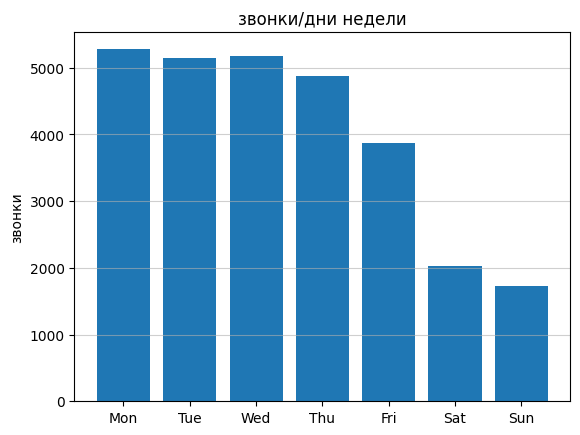

In [34]:
plt.bar(weekday_calls.index, weekday_calls.values)
plt.title("звонки/дни недели")
plt.ylabel("звонки")
plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
plt.grid(axis="y", alpha=0.6)
plt.show()

Влияет ли время покупки на вероятность звонка? Да.

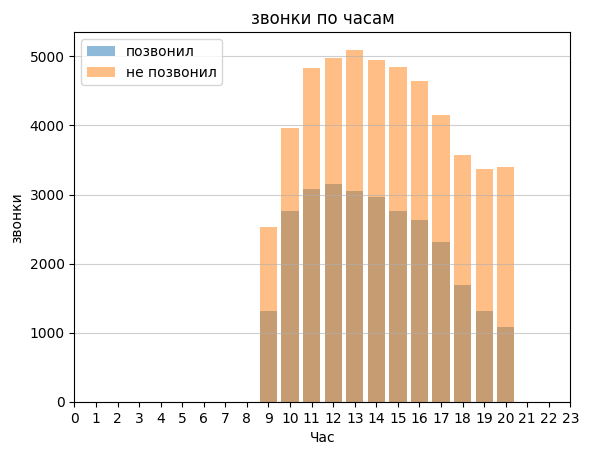

In [46]:

calls = X_trainc[X_trainc["is_callcenter"] == 1]["hour"].value_counts().sort_index()
no_calls = X_trainc[X_trainc["is_callcenter"] == 0]["hour"].value_counts().sort_index()

plt.bar(calls.index, calls.values, label="позвонил", alpha = 0.5)
plt.bar(no_calls.index, no_calls.values, label="не позвонил", alpha=0.5)

plt.title("звонки по часам")
plt.xlabel("Час")
plt.ylabel("звонки")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.6)
plt.legend()

plt.show()

In [36]:
X_train['utm_medium'].unique()


array([5, 1, 2, 3, 4, 6, 7, 8])

Было не очень понятно что это, но кажется оно тоже влияет, поэтому я оставила

In [37]:
X_trainc.groupby(['utm_medium', 'is_callcenter']).size().unstack()

is_callcenter,0,1
utm_medium,,
1,22011,13737
2,8287,3515
3,1075,603
4,5570,4416
5,6226,4069
6,5318,1071
7,1693,666
8,156,33


In [38]:
len(sorted(X_train['utm_source'].unique()))

250

In [39]:
len(X_train['parent_id'].unique())

308

In [40]:
X_train['root_id'].unique() # поэтому их я оставила, остальные признаки удалила

array([ 124,  201,  153, 1183,  255, 3368, 1493, 1504, 1481, 1634,  722,
       1794, 1478, 1595, 1342, 1633, 2303, 2433, 1795, 2176, 1792, 1793,
       3257, 6837, 1797, 2434])

In [41]:
df_web['pageview_duration_sec'].sort_values()  # не очень понятно почему отрицательные значения, но модуль ухудшал модель, поэтому я оставила как есть


2621286   -55253.0
1250517   -46325.0
3278315   -45747.0
3278314   -45471.0
1817668   -42946.0
            ...   
3334195        NaN
3334215        NaN
3334218        NaN
3334236        NaN
3334238        NaN
Name: pageview_duration_sec, Length: 3334243, dtype: float64

## Анализ данных вебстаты

Есть ли связь между позвонил ли человек от того, какую первую страничку он посмотрел? Да. Значит логично предположить, что вообще последняя страница тоже как-то влияет

In [42]:
train_m.groupby('is_callcenter')['page_type_first'].value_counts()

is_callcenter  page_type_first
0              1.0                23625
               2.0                16761
               8.0                 6137
               7.0                 1208
               3.0                  909
               4.0                  866
               6.0                  245
               nan                  187
               5.0                  103
               12.0                  80
               10.0                  78
               13.0                  64
               9.0                   55
               11.0                  18
1              1.0                14658
               2.0                10349
               8.0                 2082
               nan                  275
               7.0                  228
               3.0                  171
               4.0                  160
               10.0                  53
               12.0                  42
               5.0                   36
         

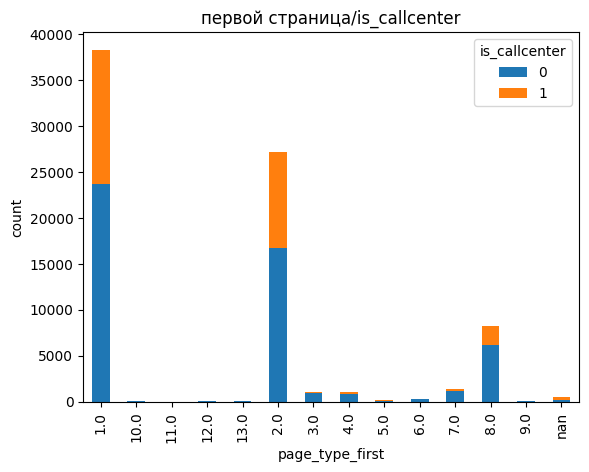

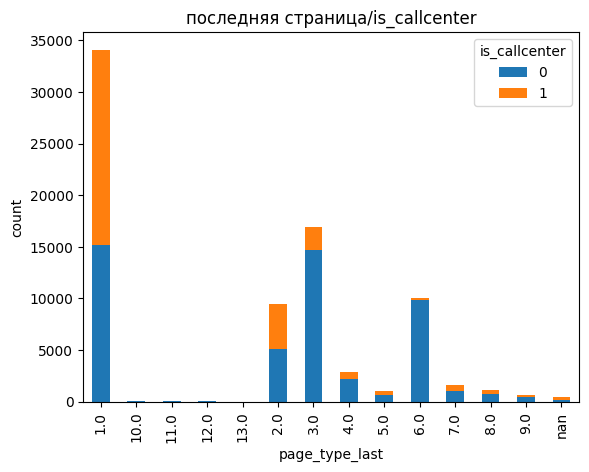

In [50]:
ct = (train_m.groupby(['page_type_first', 'is_callcenter']).size().unstack(fill_value=0).sort_index())
ct.plot(kind='bar', stacked=True)

plt.xlabel('page_type_first')
plt.ylabel('count')
plt.title('первой страница/is_callcenter')
ct = (train_m.groupby(['page_type_last', 'is_callcenter']).size().unstack(fill_value=0).sort_index())

ct.plot(kind='bar', stacked=True)

plt.xlabel('page_type_last')
plt.ylabel('count')
plt.title('последняя страница/is_callcenter')
plt.show()


Влияет ли тип страницы на время просмотра страницы (среднее по каждому типу)? Да.

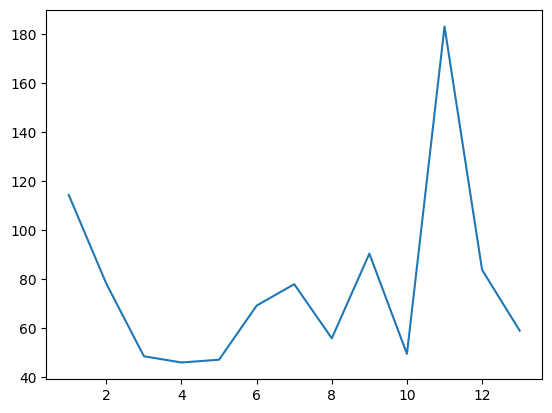

In [44]:
dfp = df_web.groupby('page_type')['pageview_duration_sec'].mean()
xx = [i for i in range(1, 14)]
plt.plot(xx, dfp.values)

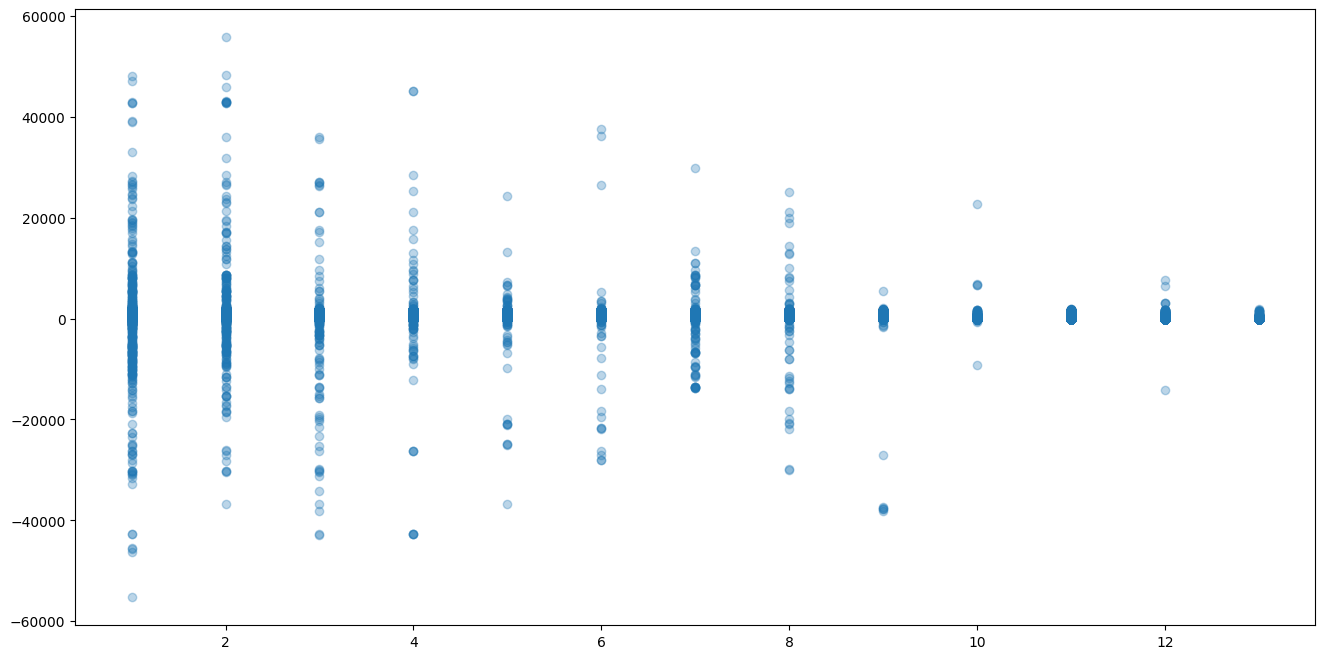

In [45]:
plt.figure(figsize=(16, 8))
plt.scatter(x=df_web['page_type'], y=df_web['pageview_duration_sec'], alpha=0.3)

Есть ли связь между кол-вом одинаковых просмотренных товаров / товаров из одной категории с звонком? Ну... немножко

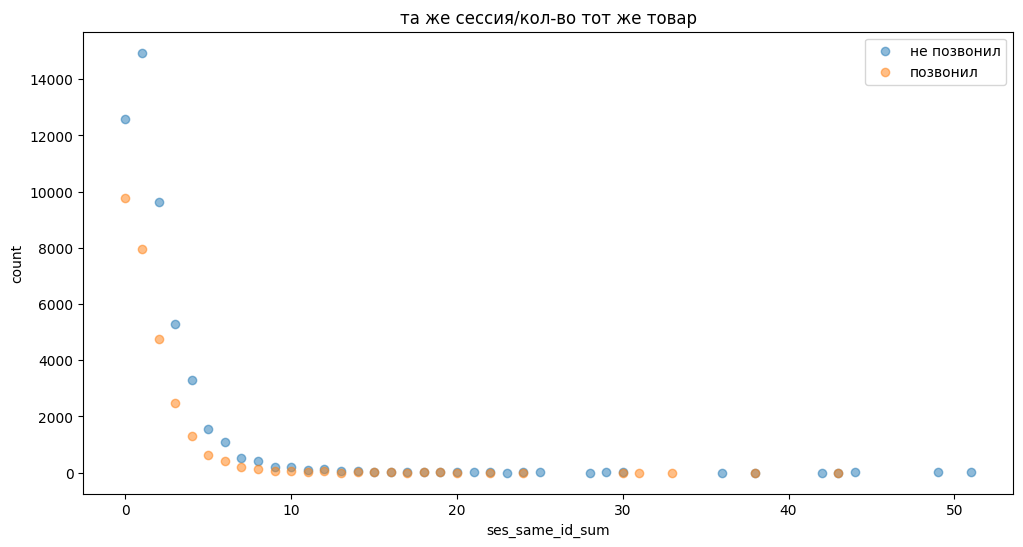

In [46]:
plt.figure(figsize=(12, 6))
tmp = (train_m.groupby(['ses_same_id_sum', 'is_callcenter']).size().reset_index(name='с'))

plt.scatter(
    tmp[tmp['is_callcenter'] == 0]['ses_same_id_sum'],
    tmp[tmp['is_callcenter'] == 0]['с'],
    label='не позвонил',
    alpha = 0.5

)

plt.scatter(
    tmp[tmp['is_callcenter'] == 1]['ses_same_id_sum'],
    tmp[tmp['is_callcenter'] == 1]['с'],
    label='позвонил',
    alpha=0.5
)

plt.xlabel('ses_same_id_sum')
plt.ylabel('count')
plt.legend()
plt.title('та же сессия/кол-во тот же товар')
plt.show()


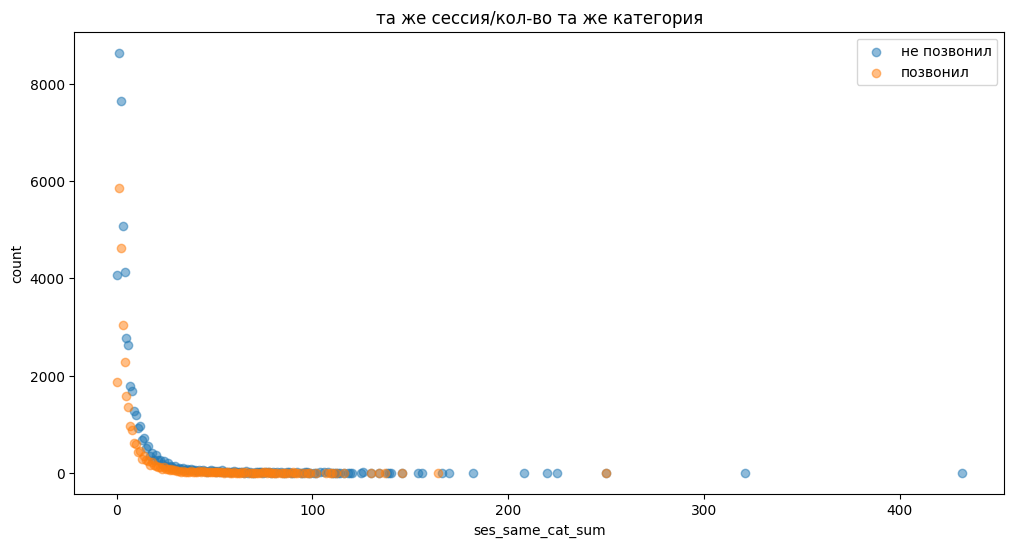

In [47]:
plt.figure(figsize=(12, 6))
tmp = (train_m.groupby(['ses_same_cat_sum', 'is_callcenter']).size().reset_index(name='с'))

plt.scatter(
    tmp[tmp['is_callcenter'] == 0]['ses_same_cat_sum'],
    tmp[tmp['is_callcenter'] == 0]['с'],
    label='не позвонил',
    alpha=0.5
)

plt.scatter(
    tmp[tmp['is_callcenter'] == 1]['ses_same_cat_sum'],
    tmp[tmp['is_callcenter'] == 1]['с'],
    label='позвонил',
    alpha=0.5
)

plt.xlabel('ses_same_cat_sum')
plt.ylabel('count')
plt.legend()
plt.title('та же сессия/кол-во та же категория')
plt.show()


## Random

Решение на чистом рандоме по приколу :D

In [48]:
num_rows = 26149
num_cols = 2

random_data = np.random.rand(num_rows, num_cols)


dfa = pd.DataFrame(random_data, columns=['id', 'is_callcenter'])

print(dfa)

             id  is_callcenter
0      0.913748       0.087755
1      0.496627       0.540590
2      0.876889       0.833849
3      0.582652       0.291961
4      0.668796       0.594125
...         ...            ...
26144  0.497749       0.673386
26145  0.829799       0.012478
26146  0.519322       0.562744
26147  0.843912       0.815312
26148  0.272864       0.553206

[26149 rows x 2 columns]


In [49]:
dfa['id'] = X_test[X_test.columns[0]].values

In [50]:
X_test[X_test.columns[0]].values

array([ 78446,  78447,  78448, ..., 104592, 104593, 104594],
      shape=(26149,))

In [51]:
dfa.set_index('id', inplace=True)

In [52]:
dfa=dfa.reset_index()

In [ ]:
dfa.to_csv('random.csv', index=False)

: 

## Заключение

#### Ход мыслей и работа
1. Сначала я сделала модель без вебстатов + логрег. Результат ~0.63 на трейне. Я удалила колонки которые не были описаны на кэггл, а также преобразовала время покупки в дни недели, часы дня, и буллевое обозначение выходного дня.
2. Потом чисто ради интереса предсказание через чистый рандом. лучший результат 0.50355. И, кстати, проходит приватный тест!
3. Добавила вебстаты. Были учтено сколько времени человек тратил на сессию, сколько страниц посетил, время просмотра сессии и вроде какие типы страниц он смотрел в целом. Результат уже сильно лучше, ~0.86. Я сравнила 3 модели - Logreg, LightGBM, Catboost, потому что они лучше всего показали себя в задании бустинг2. На одних и тех же данных получился такой рейтинг Catboost > LightGBM > Logreg.
4. Далее я решила попробовать стэкинг Logreg + LightGBM + Catboost - но логрег был сильно хуже, поэтому такой вариант стэкинга не подошел. В итоге оставила тольок LightGBM и Catboost, но тк второй был все таки немного хуже, дала LightGBM чуть больший вес. Результат стекинга - среднее значение предсказаний 2-х моделей. После стэкинга результат до 0.89 на публичных тестах. 

5. Добавила n-gramms в виде какие типы страниц посещал пользователь. Но тк их очень много было, причем если взять все вариации оно будет обучаться супердолго + риск переобучения. Я взяла только топ 100.  Причем если учитвать 3-gramms, то они ухудшали модель на 0.003, поэтому в итоге я их тоже убрала. Так результат дошел до 0.91+ и больше никак не улучшился:( На этом шаге я перестала делать кросс-валидацию, потому что из=за огромного количества фичей, она проходила оооочень медленно (даже с n_jobs).
Но, видимо это решение еще и супер нестабильное, потому что на приватных тестах произошло -0.006...



После дедлайна


6. Еще добавила сколько товаров и той же или другой категории пользователь смотрел, сколько раз других товаров и купленного товара смотрел перед заказом. Это сделало модель более стабильной и улучшило результат до 0.92

Итоговый результат на 

публичном тесте: 0.92041

приватном тесте: 0.91838
